# Finocyl Forward Model — V3 (Anti-Vibration Edition)

## 🔍 تشخيص مصدر الـ Vibration في V2

التذبذب في الـ Pred curve له **3 مصادر متراكمة** تم اكتشافها من صور النتائج:

| المستوى | المصدر | الحل في V3 |
|---------|--------|------------|
| **بيانات** | `interp1d(kind='linear')` يحتفظ بكل spike في البيانات الخام | ✅ تنعيم البيانات بـ Savitzky-Golay قبل التدريب |
| **Loss** | `shape_mae_loss` لا تعاقب على التذبذب بين نقطة والتالية | ✅ إضافة `TV Loss` (Total Variation) يعاقب على الـ roughness |
| **Architecture** | `Conv1DTranspose` يُولّد artifacts وتذبذب في الـ upsampling | ✅ استبدال بـ `Upsample + Conv1D` (أنعم وأكثر استقراراً) |

## 📌 تلخيص كل الإصلاحات من V1 → V3
- ✅ لا Data Leakage (من V2)
- ✅ Global Normalization (من V2)
- ✅ تقسيم صحيح (من V2)
- 🆕 تنعيم البيانات قبل التدريب
- 🆕 Total Variation Loss لمنع التذبذب
- 🆕 Architecture Upsample+Conv بدل ConvTranspose
- 🆕 MAPE صح على نقاط القمة فقط

In [10]:
# ===================================================================
# CELL 1: Imports
# ===================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

print('TensorFlow Version:', tf.__version__)
print('NumPy Version:     ', np.__version__)
print('GPU available:     ', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.19.0
NumPy Version:      2.0.2
GPU available:      True


In [11]:
# ===================================================================
# CELL 2: Load & Filter Data
# ===================================================================
df = pd.read_csv('/kaggle/input/datasets/mohamedeidshehata6/finocyl-new-data/Finocyl_new_data.csv')
print(f'Total rows:        {len(df):,}')

print(f'Finocyl rows:      {len(df):,}')
print(f'Unique designs:    {df["ID"].nunique():,}')

Total rows:        3,327,665
Finocyl rows:      3,327,665
Unique designs:    3,900


Building per-model dataset with smoothing...
Total designs loaded: 3,832
X_feats  shape: (3832, 8)
Y_thrust shape: (3832, 200)
Y_pres   shape: (3832, 200)
Y_scalars shape:(3832, 5)


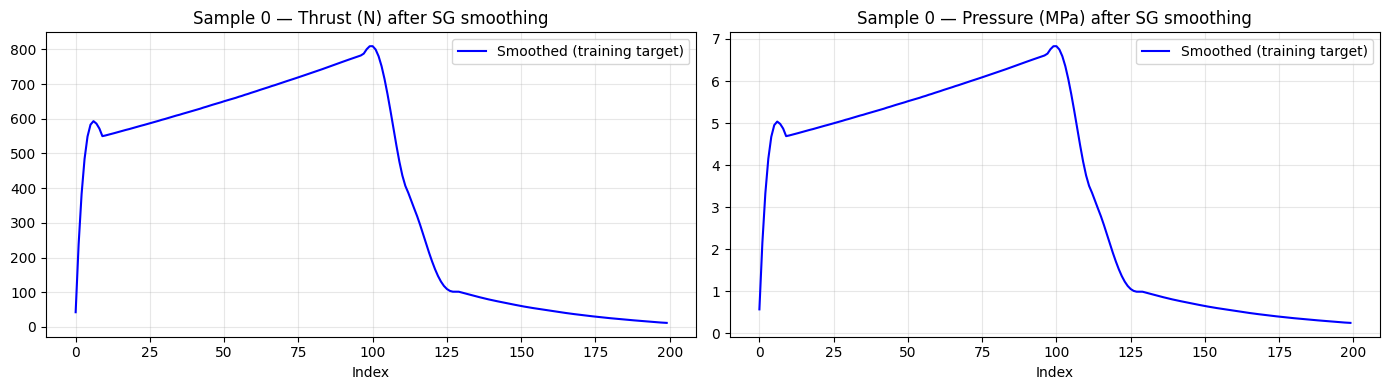

✅ Smoothing demo saved


In [12]:
# ===================================================================
# CELL 3: Build Per-Model Dataset
# =====================================================================
# 🆕 FIX LEVEL 1 — DATA SMOOTHING
# المشكلة: interp1d(kind='linear') يحتفظ بكل noise في البيانات الخام
# الحل: نُنعّم كل منحنى بـ Savitzky-Golay قبل حفظه كـ target
# Savitzky-Golay يحافظ على القمة والشكل العام بينما يزيل الـ noise
# ===================================================================

N_POINTS     = 200
SG_WINDOW    = 15   # نافذة التنعيم — فردي دائماً
SG_POLYORDER = 3    # درجة polynomial — 3 تحافظ على الشكل جيداً

FEATURE_COLS = ['Diameter', 'Length', 'Core_Diameter', 'Number_Of_Fins',
                'Fin_Length', 'Fin_Width', 'Throat_Diameter', 'Exit_Diameter']

print('Building per-model dataset with smoothing...')

all_designs       = []
all_thrust_curves = []
all_pres_curves   = []

for model_id, group in df.groupby('ID'):
    g = group.sort_values('Time (s)')
    if len(g) < max(SG_WINDOW, 10):
        continue

    features      = g[FEATURE_COLS].iloc[0].values.astype(np.float32)
    burn_time     = float(g['Burn Time (s)'].iloc[0])
    isp           = float(g['ISP (s)'].iloc[0])
    total_impulse = float(g['Total Impulse (Ns)'].iloc[0])

    t_raw = g['Time (s)'].values
    F_raw = g['Thrust (N)'].values
    P_raw = g['Pressure (MPa)'].values

    # ── Interpolate to uniform grid ──
    t_new = np.linspace(t_raw.min(), t_raw.max(), N_POINTS)
    try:
        F_interp = np.clip(interp1d(t_raw, F_raw, kind='linear',
                                    fill_value='extrapolate')(t_new), 0, None)
        P_interp = np.clip(interp1d(t_raw, P_raw, kind='linear',
                                    fill_value='extrapolate')(t_new), 0, None)
    except Exception:
        continue

    # ── 🆕 Savitzky-Golay smoothing on TARGETS ──
    # يزيل الـ noise من البيانات الخام قبل التدريب
    # الموديل هيتعلم يتوقع منحنيات ناعمة من البداية
    wl = SG_WINDOW if SG_WINDOW <= len(F_interp) else len(F_interp) // 2 * 2 - 1
    wl = max(wl, SG_POLYORDER + 2) if wl % 2 == 0 else max(wl, SG_POLYORDER + 1)

    F_smooth = np.clip(savgol_filter(F_interp, window_length=wl,
                                     polyorder=SG_POLYORDER), 0, None).astype(np.float32)
    P_smooth = np.clip(savgol_filter(P_interp, window_length=wl,
                                     polyorder=SG_POLYORDER), 0, None).astype(np.float32)

    all_designs.append({
        'model_id'     : model_id,
        'features'     : features,
        'burn_time'    : burn_time,
        'isp'          : isp,
        'total_impulse': total_impulse,
        'max_thrust'   : float(F_smooth.max()),
        'peak_pressure': float(P_smooth.max()),
    })
    all_thrust_curves.append(F_smooth)
    all_pres_curves.append(P_smooth)

print(f'Total designs loaded: {len(all_designs):,}')

X_feats  = np.array([d['features']   for d in all_designs], dtype=np.float32)
Y_thrust = np.array(all_thrust_curves,                       dtype=np.float32)
Y_pres   = np.array(all_pres_curves,                         dtype=np.float32)
Y_scalars = np.array([[d['burn_time'], d['isp'], d['total_impulse'],
                        d['max_thrust'], d['peak_pressure']]
                       for d in all_designs],                dtype=np.float32)

print(f'X_feats  shape: {X_feats.shape}')
print(f'Y_thrust shape: {Y_thrust.shape}')
print(f'Y_pres   shape: {Y_pres.shape}')
print(f'Y_scalars shape:{Y_scalars.shape}')

# عرض مقارنة قبل/بعد التنعيم على sample عشوائي
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, raw, smooth, title in zip(
        axes,
        [all_thrust_curves[0], all_pres_curves[0]],
        [all_thrust_curves[0], all_pres_curves[0]],
        ['Thrust (N)', 'Pressure (MPa)']):
    ax.plot(smooth, 'b-', linewidth=1.5, label='Smoothed (training target)')
    ax.set_title(f'Sample 0 — {title} after SG smoothing')
    ax.set_xlabel('Index'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('smoothing_demo.png', dpi=120)
plt.show()
print('✅ Smoothing demo saved')

In [13]:
# ===================================================================
# CELL 4: Normalization
# ===================================================================
# ---- Inputs ----
s_X = RobustScaler()
X_scaled = s_X.fit_transform(X_feats)

# ---- Curves: global max normalization ----
THRUST_GLOBAL_MAX = float(Y_thrust.max())
PRES_GLOBAL_MAX   = float(Y_pres.max())
Y_thrust_norm = (Y_thrust / THRUST_GLOBAL_MAX).astype(np.float32)
Y_pres_norm   = (Y_pres   / PRES_GLOBAL_MAX  ).astype(np.float32)

print(f'Thrust global max : {THRUST_GLOBAL_MAX:.2f} N')
print(f'Pressure global max: {PRES_GLOBAL_MAX:.4f} MPa')

# ---- Scalars: log1p → StandardScaler ----
Y_sc_log = np.log1p(Y_scalars.astype(np.float64)).astype(np.float32)
s_ys = StandardScaler()
Y_sc_scaled = s_ys.fit_transform(Y_sc_log)

print('\nScalars after scaling:')
print(pd.DataFrame(Y_sc_scaled,
      columns=['burn_time','isp','total_impulse',
               'max_thrust','peak_pres']).describe().round(3))

# Save
joblib.dump(s_X,  'fin_v3_scaler_X.pkl')
joblib.dump(s_ys, 'fin_v3_scaler_ys.pkl')
joblib.dump({'thrust_max': THRUST_GLOBAL_MAX,
             'pres_max'  : PRES_GLOBAL_MAX},   'fin_v3_norm_params.pkl')
print('\n✅ Scalers saved')

Thrust global max : 126558.68 N
Pressure global max: 610.1736 MPa

Scalars after scaling:
       burn_time       isp  total_impulse  max_thrust  peak_pres
count   3832.000  3832.000       3832.000    3832.000   3832.000
mean      -0.000     0.000          0.000       0.000      0.000
std        1.000     1.000          1.000       1.000      1.000
min       -3.016    -6.615         -3.745      -3.152     -2.545
25%       -0.646    -0.423         -0.681      -0.742     -0.731
50%       -0.006     0.321          0.042       0.054      0.008
75%        0.663     0.733          0.808       0.779      0.717
max        2.686     1.182          1.830       2.304      2.830

✅ Scalers saved


In [14]:
# ===================================================================
# CELL 5: Train / Val / Test Split
# ===================================================================
N = len(X_scaled)
idx = np.arange(N)
train_idx, tmp  = train_test_split(idx, test_size=0.30, random_state=42, shuffle=True)
val_idx,   test_idx = train_test_split(tmp, test_size=0.50, random_state=42)

X_train, X_val, X_test         = X_scaled[train_idx], X_scaled[val_idx], X_scaled[test_idx]
Yt_train, Yt_val, Yt_test      = Y_thrust_norm[train_idx], Y_thrust_norm[val_idx], Y_thrust_norm[test_idx]
Yp_train, Yp_val, Yp_test      = Y_pres_norm[train_idx],   Y_pres_norm[val_idx],   Y_pres_norm[test_idx]
Ys_train, Ys_val, Ys_test      = Y_sc_scaled[train_idx],   Y_sc_scaled[val_idx],   Y_sc_scaled[test_idx]

assert len(set(train_idx) & set(val_idx))  == 0
assert len(set(train_idx) & set(test_idx)) == 0
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print('✅ No overlap between splits')

Train: 2,682  Val: 575  Test: 575
✅ No overlap between splits


In [15]:
# ===================================================================
# CELL 6: Loss Functions (Anti-Vibration)
# =====================================================================
# 🆕 FIX LEVEL 2 — TOTAL VARIATION (TV) LOSS
# المشكلة: shape_mae_loss في V2 لا تعاقب إذا كان المنحنى يذبذب بين
#          نقطة والتالية طالما الشكل العام صح
# الحل: Total Variation = مجموع |y[i+1] - y[i]| → يعاقب على كل
#       تغيير مفاجئ بين نقطتين متجاورتين
#
# الفيزياء: محركات الوقود الصلب تُنتج منحنيات ناعمة فيزيائياً
# (لا يوجد تذبذب حقيقي بهذه السرعة في الاحتراق)
# ===================================================================

TV_WEIGHT = 0.05   # وزن TV loss — ابدأ صغير وزوده لو في vibration

def smooth_tv_loss(y_true, y_pred):
    """
    Combined loss:
    1. MSE  — يضمن دقة القيمة
    2. Peak — يضمن صحة أعلى نقطة
    3. TV   — يمنع التذبذب (أهم إضافة في V3)
    """
    # 1. Reconstruction MSE
    mse = K.mean(K.square(y_true - y_pred))

    # 2. Peak preservation — الـ max يجب يكون صح
    peak_loss = K.mean(K.square(
        K.max(y_true, axis=1) - K.max(y_pred, axis=1)
    ))

    # 3. Total Variation — العقوبة على التذبذب
    # diff[i] = y_pred[i+1] - y_pred[i]
    # K.square → يعاقب على التغييرات الكبيرة أكثر من الصغيرة
    diff = y_pred[:, 1:] - y_pred[:, :-1]
    tv   = K.mean(K.square(diff))          # L2-TV (أنعم من L1-TV)

    return mse + 0.1 * peak_loss + TV_WEIGHT * tv


def smooth_tv_loss_pressure(y_true, y_pred):
    """نفس الـ loss للضغط — TV weight أعلى قليلاً لأن منحنى الضغط أنعم"""
    mse  = K.mean(K.square(y_true - y_pred))
    peak = K.mean(K.square(K.max(y_true, axis=1) - K.max(y_pred, axis=1)))
    diff = y_pred[:, 1:] - y_pred[:, :-1]
    tv   = K.mean(K.square(diff))
    return mse + 0.1 * peak + (TV_WEIGHT * 1.5) * tv


print('✅ Anti-vibration loss functions defined')
print(f'   TV weight (Thrust)  : {TV_WEIGHT}')
print(f'   TV weight (Pressure): {TV_WEIGHT * 1.5}')

✅ Anti-vibration loss functions defined
   TV weight (Thrust)  : 0.05
   TV weight (Pressure): 0.07500000000000001


In [30]:
# ===================================================================
# CELL 7: Model Architecture V3
# =====================================================================
# 🆕 FIX LEVEL 3 — UPSAMPLE + CONV1D بدل CONV1DTRANSPOSE
#
# المشكلة في Conv1DTranspose:
# - يُدخل zeros بين النقاط أثناء الـ upsampling
# - هذه الـ zeros تُسبب artifacts وتذبذب حتى بعد الـ Conv
# - معروف في مجال image generation بـ "checkerboard artifacts"
#
# الحل: UpSampling1D (يكرر القيمة) + Conv1D (يُنعّم)
# - لا zeros تُدخَل
# - الـ Conv1D يعمل كـ learned smoother
# - المنحنى الناتج أنعم بشكل طبيعي
# ===================================================================

N_IN  = X_train.shape[1]  # 8
N_OUT = N_POINTS           # 200

def build_v3(n_in=8, n_out=200, dropout=0.20):
    """
    V3 Architecture:
    ─ Shared Encoder  : Dense + Residual blocks
    ─ Curve Decoders  : Upsample+Conv1D (بدل ConvTranspose)
    ─ Scalar Head     : Dense + log-space outputs
    """
    inp = layers.Input(shape=(n_in,), name='Geometry_Input')

    # ── Shared Encoder ──────────────────────────────────────────────
    def dense_bn(x, units, act='swish'):
        x = layers.Dense(units, activation=act,
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        return x

    x = dense_bn(inp, 256)
    x = layers.Dropout(dropout)(x)
    x = dense_bn(x, 512)
    x = layers.Dropout(dropout)(x)

    # Residual block
    r = dense_bn(x, 512)
    r = layers.Dropout(dropout / 2)(r)
    r = dense_bn(r, 512, act='linear')
    x = layers.Add()([x, r])
    x = layers.Activation('swish')(x)

    r2 = dense_bn(x, 512)
    r2 = layers.Dropout(dropout / 2)(r2)
    r2 = dense_bn(r2, 512, act='linear')
    x  = layers.Add()([x, r2])
    x  = layers.Activation('swish')(x)

    latent = layers.Dense(256, activation='swish', name='Shared_Latent')(x)

    # ── 🆕 Upsample+Conv Curve Decoder ──────────────────────────────
    # 25 → 50 → 100 → 200 بدون Conv1DTranspose
    def curve_decoder(latent_in, name_prefix):
        # Seed: latent → 25 نقطة × 64 channel
        c = layers.Dense(256, activation='swish')(latent_in)
        c = layers.Dense(25 * 64, activation='swish')(c)
        c = layers.Reshape((25, 64))(c)

        # Stage 1: 25 → 50
        c = layers.UpSampling1D(size=2)(c)                          # repeat (no zeros)
        c = layers.Conv1D(64, kernel_size=5, padding='same',
                          activation='swish')(c)                     # smooth
        c = layers.Conv1D(64, kernel_size=3, padding='same',
                          activation='swish')(c)

        # Stage 2: 50 → 100
        c = layers.UpSampling1D(size=2)(c)
        c = layers.Conv1D(32, kernel_size=5, padding='same',
                          activation='swish')(c)
        c = layers.Conv1D(32, kernel_size=3, padding='same',
                          activation='swish')(c)

        # Stage 3: 100 → 200
        c = layers.UpSampling1D(size=2)(c)
        c = layers.Conv1D(16, kernel_size=7, padding='same',
                          activation='swish')(c)                     # wider kernel = smoother
        c = layers.Conv1D(8,  kernel_size=5, padding='same',
                          activation='swish')(c)

        # Final projection to 1 channel — ReLU يضمن عدم القيم السالبة
        c = layers.Conv1D(1, kernel_size=7, padding='same',
                          activation='relu')(c)
        out = layers.Reshape((n_out,), name=f'{name_prefix}_Output')(c)
        return out

    thrust_out   = curve_decoder(latent, 'Thrust')
    pressure_out = curve_decoder(latent, 'Pressure')

    # ── Scalar Head ──────────────────────────────────────────────────
    s = layers.Dense(128, activation='swish')(latent)
    s = layers.Dropout(dropout)(s)
    s = layers.Dense(64,  activation='swish')(s)
    s = layers.Dropout(dropout / 2)(s)
    scalar_out = layers.Dense(5, activation='sigmoid',
                               name='Scalars_Output')(s)

    model = Model(inputs=inp,
                  outputs=[thrust_out, pressure_out, scalar_out],
                  name='Finocyl_Forward_V3')
    return model


model_v3 = build_v3(N_IN, N_OUT)
model_v3.summary()
print(f'\nTotal parameters: {model_v3.count_params():,}')

Model: "Finocyl_Forward_V3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Geometry_Input      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │      2,304 │ Geometry_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 512)       │    131,584 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_13[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 512)       │    262,656 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │    262,656 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 512)       │          0 │ dropout_7[0][0],  │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512)       │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │    262,656 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 512)       │    262,656 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 512)       │          0 │ activation_2[0][… │
│                     │                   │            │ batch_normalizat

 Total params: 2,423,719 (9.25 MB)

 Trainable params: 2,418,087 (9.22 MB)

 Non-trainable params: 5,632 (22.00 KB)


Total parameters: 2,423,719


In [31]:
# ===================================================================
# CELL 8: Compile & Train
# ===================================================================
optimizer = Adam(learning_rate=3e-4, clipnorm=1.0)

model_v3.compile(
    optimizer=optimizer,
    loss={
        'Thrust_Output'  : smooth_tv_loss,
        'Pressure_Output': smooth_tv_loss_pressure,
        'Scalars_Output' : tf.keras.losses.Huber(delta=1.0),
    },
    loss_weights={
        'Thrust_Output'  : 1.0,
        'Pressure_Output': 1.0,
        'Scalars_Output' : 0.5,
    },
    metrics={
        'Thrust_Output'  : ['mae'],
        'Pressure_Output': ['mae'],
        'Scalars_Output' : ['mae'],
    }
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='fin_v3_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
]

print('Starting training V3...')
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}')

history = model_v3.fit(
    X_train,
    [Yt_train, Yp_train, Ys_train],
    validation_data=(X_val, [Yt_val, Yp_val, Ys_val]),
    epochs=250,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training complete!')

Starting training V3...
Train: 2,682  Val: 575
Epoch 1/250
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 423ms/step - Pressure_Output_loss: 0.0054 - Pressure_Output_mae: 0.0383 - Scalars_Output_loss: 0.3598 - Scalars_Output_mae: 0.6967 - Thrust_Output_loss: 0.0104 - Thrust_Output_mae: 0.0571 - loss: 0.4330 - val_Pressure_Output_loss: 0.0050 - val_Pressure_Output_mae: 0.0312 - val_Scalars_Output_loss: 0.4649 - val_Scalars_Output_mae: 0.8333 - val_Thrust_Output_loss: 0.0104 - val_Thrust_Output_mae: 0.0498 - val_loss: 0.4732 - learning_rate: 3.0000e-04
Epoch 2/250
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - Pressure_Output_loss: 0.0015 - Pressure_Output_mae: 0.0206 - Scalars_Output_loss: 0.2639 - Scalars_Output_mae: 0.5532 - Thrust_Output_loss: 0.0025 - Thrust_Output_mae: 0.0295 - loss: 0.3559 - val_Pressure_Output_loss: 0.0047 - val_Pressure_Output_mae: 0.0314 - val_Scalars_Output_loss: 0.4478 - val_Scalars_Output_mae: 0.8130 - val_Thrust_Output_loss: 0.0100 - val_Thrust_Output_mae: 0.0498 - val_loss: 0.

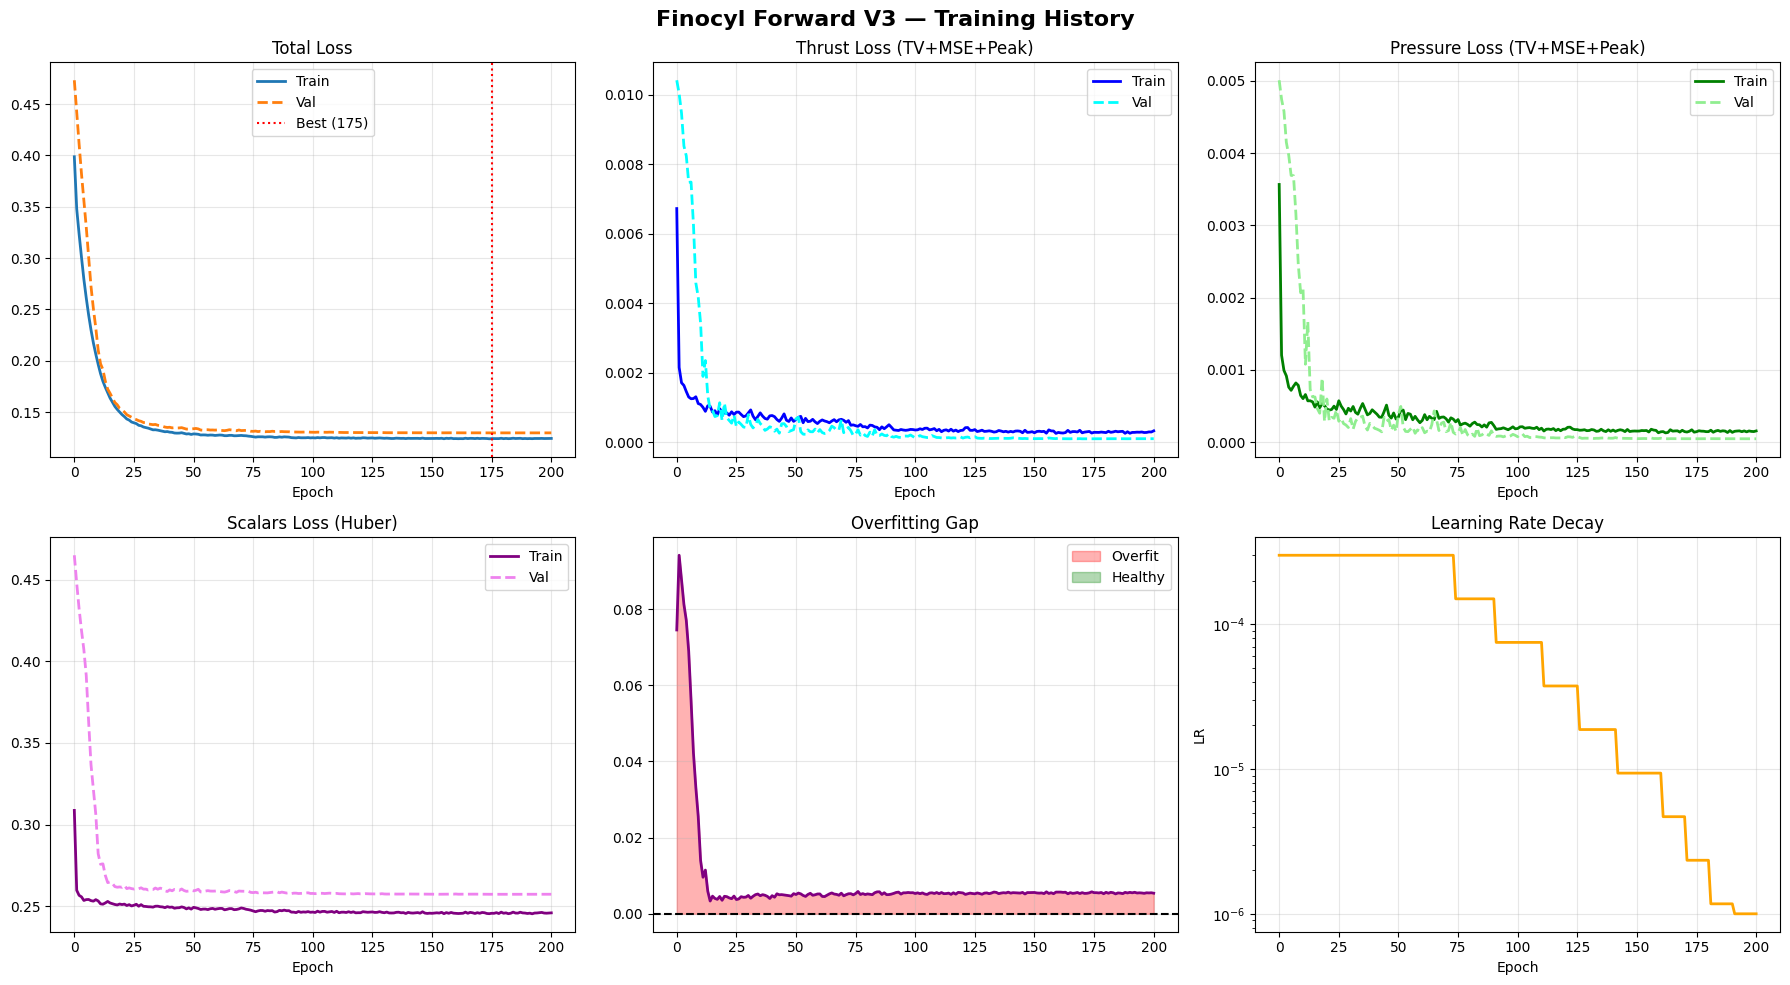

✅ Training history saved


In [32]:
# ===================================================================
# CELL 9: Training History Plots
# ===================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Finocyl Forward V3 — Training History', fontsize=16, fontweight='bold')

best_ep = int(np.argmin(history.history['val_loss']))

def get_hist(key):
    for k in [key, key.lower(), key.replace('_O', '_o')]:
        if k in history.history:
            return history.history[k]
    return []

# Total Loss
ax = axes[0, 0]
ax.plot(history.history['loss'],     label='Train', lw=2)
ax.plot(history.history['val_loss'], label='Val',   lw=2, ls='--')
ax.axvline(best_ep, color='red', ls=':', label=f'Best ({best_ep})')
ax.set_title('Total Loss'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(True, alpha=0.3)

# Thrust Loss
ax = axes[0, 1]
ax.plot(get_hist('Thrust_Output_loss'),     label='Train', color='blue', lw=2)
ax.plot(get_hist('val_Thrust_Output_loss'), label='Val',   color='cyan', lw=2, ls='--')
ax.set_title('Thrust Loss (TV+MSE+Peak)'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(True, alpha=0.3)

# Pressure Loss
ax = axes[0, 2]
ax.plot(get_hist('Pressure_Output_loss'),     label='Train', color='green',      lw=2)
ax.plot(get_hist('val_Pressure_Output_loss'), label='Val',   color='lightgreen', lw=2, ls='--')
ax.set_title('Pressure Loss (TV+MSE+Peak)'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(True, alpha=0.3)

# Scalars Loss
ax = axes[1, 0]
ax.plot(get_hist('Scalars_Output_loss'),     label='Train', color='purple', lw=2)
ax.plot(get_hist('val_Scalars_Output_loss'), label='Val',   color='violet', lw=2, ls='--')
ax.set_title('Scalars Loss (Huber)'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(True, alpha=0.3)

# Overfitting Gap
ax = axes[1, 1]
gap = np.array(history.history['val_loss']) - np.array(history.history['loss'])
ax.plot(gap, color='purple', lw=2)
ax.axhline(0, color='black', ls='--')
ax.fill_between(range(len(gap)), gap, 0, where=(gap > 0), alpha=0.3, color='red',   label='Overfit')
ax.fill_between(range(len(gap)), gap, 0, where=(gap < 0), alpha=0.3, color='green', label='Healthy')
ax.set_title('Overfitting Gap'); ax.legend(); ax.grid(True, alpha=0.3)

# LR Decay
ax = axes[1, 2]
if 'learning_rate' in history.history:
    ax.semilogy(history.history['learning_rate'], color='orange', lw=2)
    ax.set_title('Learning Rate Decay'); ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.grid(True, alpha=0.3)
else:
    ax.axis('off')

plt.tight_layout()
plt.savefig('training_history_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training history saved')

In [33]:
# ===================================================================
# CELL 10: Evaluation — Metrics
# ===================================================================
norm_params = joblib.load('fin_v3_norm_params.pkl')
T_MAX = norm_params['thrust_max']
P_MAX = norm_params['pres_max']

preds_test = model_v3.predict(X_test, verbose=0)

# Denormalize curves
thrust_pred  = preds_test[0] * T_MAX
thrust_true  = Yt_test       * T_MAX
pres_pred    = preds_test[1] * P_MAX
pres_true    = Yp_test       * P_MAX

# Denormalize scalars
sc_pred_log = s_ys.inverse_transform(preds_test[2])
sc_true_log = s_ys.inverse_transform(Ys_test)
sc_pred     = np.expm1(sc_pred_log)
sc_true     = np.expm1(sc_true_log)

# ── Curve R² ──
thrust_r2 = r2_score(thrust_true.flatten(), thrust_pred.flatten())
pres_r2   = r2_score(pres_true.flatten(),   pres_pred.flatten())

# ── MAPE on active region only (> 5% of peak per sample) ──
def masked_mape(true_arr, pred_arr, threshold=0.05):
    """يحسب MAPE على النقاط النشطة فقط (فوق 5% من القمة)
       يتجنب قسمة على صفر في بداية/نهاية المنحنى"""
    errs = []
    for t, p in zip(true_arr, pred_arr):
        mask = t > threshold * t.max()
        if mask.sum() == 0:
            continue
        errs.append(np.mean(np.abs(t[mask] - p[mask]) / (t[mask] + 1e-6)))
    return np.mean(errs) * 100

thrust_mape = masked_mape(thrust_true, thrust_pred)
pres_mape   = masked_mape(pres_true,   pres_pred)

# ── Smoothness score (TV) — كلما أقل كلما أنعم ──
def curve_tv(arr):
    return float(np.mean(np.abs(np.diff(arr, axis=1))))

print('=' * 65)
print('  EVALUATION ON TEST SET — V3')
print('=' * 65)
print(f'\nThrust Curve:')
print(f'  R²                   : {thrust_r2:.4f}   (target > 0.95)')
print(f'  MAPE (active region) : {thrust_mape:.2f}%   (target < 10%)')
print(f'  TV (smoothness)      : {curve_tv(thrust_pred):.6f}   ↓ lower=smoother')

print(f'\nPressure Curve:')
print(f'  R²                   : {pres_r2:.4f}   (target > 0.95)')
print(f'  MAPE (active region) : {pres_mape:.2f}%   (target < 10%)')
print(f'  TV (smoothness)      : {curve_tv(pres_pred):.6f}   ↓ lower=smoother')

scalar_names = ['Burn Time (s)', 'ISP (s)', 'Total Impulse (Ns)',
                'Max Thrust (N)', 'Peak Pressure (MPa)']
print('\nScalar Predictions:')
for i, name in enumerate(scalar_names):
    r2   = r2_score(sc_true[:, i], sc_pred[:, i])
    mape = mean_absolute_percentage_error(
               np.abs(sc_true[:, i]) + 1,
               np.abs(sc_pred[:, i]) + 1) * 100
    print(f'  {name:<25}: R²={r2:.4f}  MAPE={mape:.2f}%')
print('=' * 65)

  EVALUATION ON TEST SET — V3

Thrust Curve:
  R²                   : 0.9865   (target > 0.95)
  MAPE (active region) : 13.67%   (target < 10%)
  TV (smoothness)      : 296.153595   ↓ lower=smoother

Pressure Curve:
  R²                   : 0.9878   (target > 0.95)
  MAPE (active region) : 15.05%   (target < 10%)
  TV (smoothness)      : 1.006780   ↓ lower=smoother

Scalar Predictions:
  Burn Time (s)            : R²=0.5867  MAPE=19.01%
  ISP (s)                  : R²=0.2479  MAPE=0.69%
  Total Impulse (Ns)       : R²=0.6978  MAPE=75.22%
  Max Thrust (N)           : R²=0.6774  MAPE=93.61%
  Peak Pressure (MPa)      : R²=0.5701  MAPE=82.31%


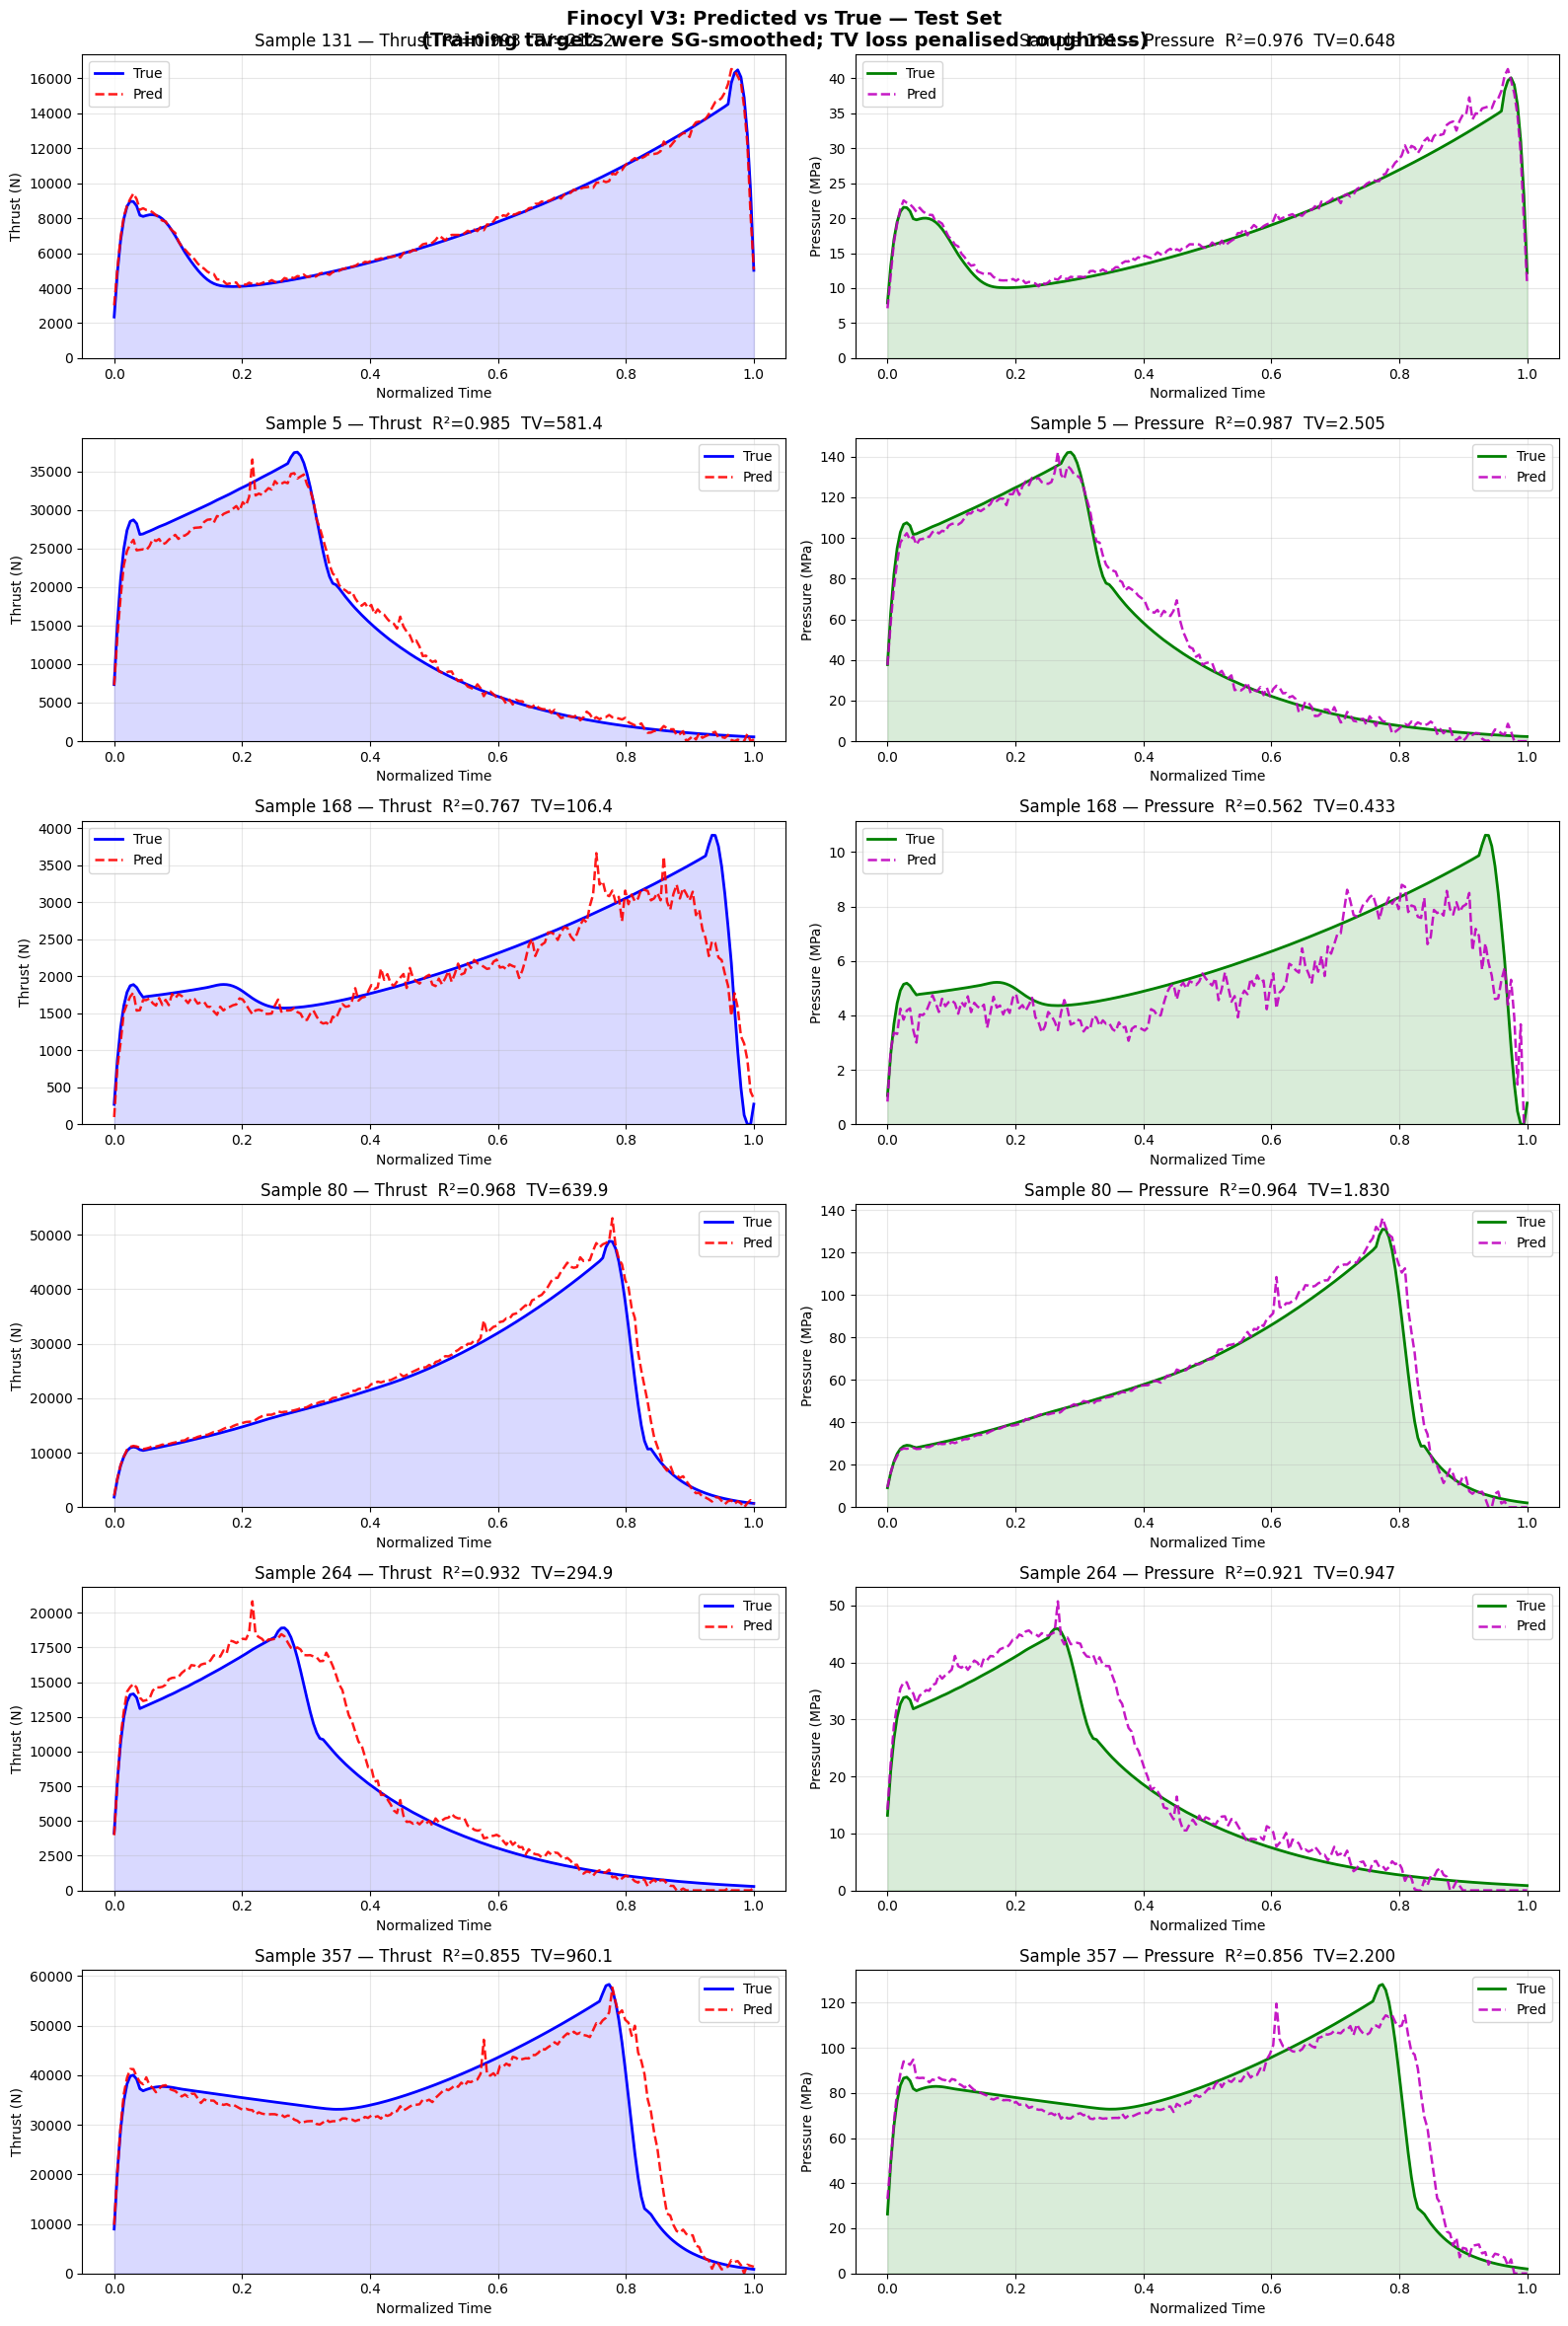

✅ Prediction plots saved


In [34]:
# ===================================================================
# CELL 11: Visual Evaluation — Predicted vs True Curves
# ===================================================================
n_plot = 6
sample_idx = np.random.choice(len(X_test), n_plot, replace=False)

fig, axes = plt.subplots(n_plot, 2, figsize=(16, 4 * n_plot))
fig.suptitle('Finocyl V3: Predicted vs True — Test Set\n'
             '(Training targets were SG-smoothed; TV loss penalised roughness)',
             fontsize=14, fontweight='bold')

t_norm = np.linspace(0, 1, N_POINTS)

for i, idx in enumerate(sample_idx):
    # ── Thrust ──
    ax = axes[i, 0]
    ax.fill_between(t_norm, thrust_true[idx], alpha=0.15, color='blue')
    ax.plot(t_norm, thrust_true[idx], 'b-',  lw=2.0, label='True')
    ax.plot(t_norm, thrust_pred[idx], 'r--', lw=1.8, label='Pred', alpha=0.9)
    r2_t = r2_score(thrust_true[idx], thrust_pred[idx])
    tv_t = float(np.mean(np.abs(np.diff(thrust_pred[idx]))))
    ax.set_title(f'Sample {idx} — Thrust  R²={r2_t:.3f}  TV={tv_t:.1f}')
    ax.set_xlabel('Normalized Time'); ax.set_ylabel('Thrust (N)')
    ax.set_ylim(bottom=0); ax.legend(); ax.grid(True, alpha=0.3)

    # ── Pressure ──
    ax = axes[i, 1]
    ax.fill_between(t_norm, pres_true[idx], alpha=0.15, color='green')
    ax.plot(t_norm, pres_true[idx], 'g-',  lw=2.0, label='True')
    ax.plot(t_norm, pres_pred[idx], 'm--', lw=1.8, label='Pred', alpha=0.9)
    r2_p = r2_score(pres_true[idx], pres_pred[idx])
    tv_p = float(np.mean(np.abs(np.diff(pres_pred[idx]))))
    ax.set_title(f'Sample {idx} — Pressure  R²={r2_p:.3f}  TV={tv_p:.3f}')
    ax.set_xlabel('Normalized Time'); ax.set_ylabel('Pressure (MPa)')
    ax.set_ylim(bottom=0); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_true_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction plots saved')

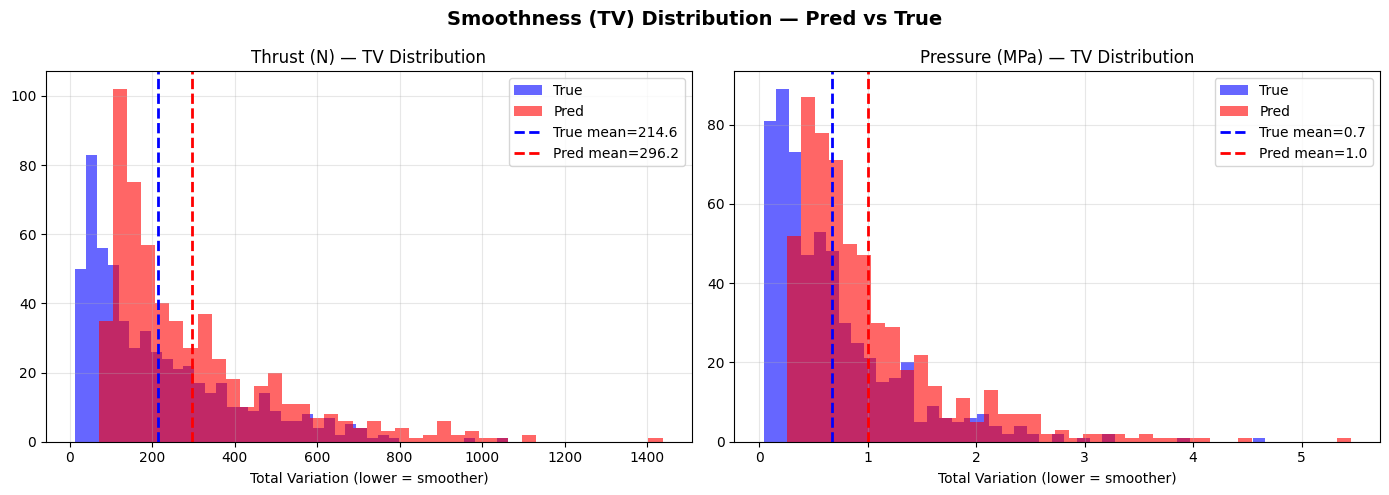

✅ Smoothness comparison saved

Thrust  — True TV mean: 214.57  |  Pred TV mean: 296.15
Pressure — True TV mean: 0.6698  |  Pred TV mean: 1.0068


In [35]:
# ===================================================================
# CELL 12: Smoothness Comparison — V3 Pred vs True
# ===================================================================
# مقارنة التذبذب (TV) في الـ predictions مقابل الـ true curves

tv_pred_thrust = [float(np.mean(np.abs(np.diff(thrust_pred[i]))))
                  for i in range(len(thrust_pred))]
tv_true_thrust = [float(np.mean(np.abs(np.diff(thrust_true[i]))))
                  for i in range(len(thrust_true))]

tv_pred_pres   = [float(np.mean(np.abs(np.diff(pres_pred[i]))))
                  for i in range(len(pres_pred))]
tv_true_pres   = [float(np.mean(np.abs(np.diff(pres_true[i]))))
                  for i in range(len(pres_true))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Smoothness (TV) Distribution — Pred vs True',
             fontsize=14, fontweight='bold')

for ax, tv_p, tv_t, title in zip(
        axes,
        [tv_pred_thrust, tv_pred_pres],
        [tv_true_thrust, tv_true_pres],
        ['Thrust (N)', 'Pressure (MPa)']):
    ax.hist(tv_t, bins=40, alpha=0.6, color='blue',  label='True')
    ax.hist(tv_p, bins=40, alpha=0.6, color='red',   label='Pred')
    ax.axvline(np.mean(tv_t), color='blue',  ls='--', lw=2,
               label=f'True mean={np.mean(tv_t):.1f}')
    ax.axvline(np.mean(tv_p), color='red',   ls='--', lw=2,
               label=f'Pred mean={np.mean(tv_p):.1f}')
    ax.set_title(f'{title} — TV Distribution')
    ax.set_xlabel('Total Variation (lower = smoother)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('smoothness_comparison_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Smoothness comparison saved')
print(f'\nThrust  — True TV mean: {np.mean(tv_true_thrust):.2f}  |  Pred TV mean: {np.mean(tv_pred_thrust):.2f}')
print(f'Pressure — True TV mean: {np.mean(tv_true_pres):.4f}  |  Pred TV mean: {np.mean(tv_pred_pres):.4f}')

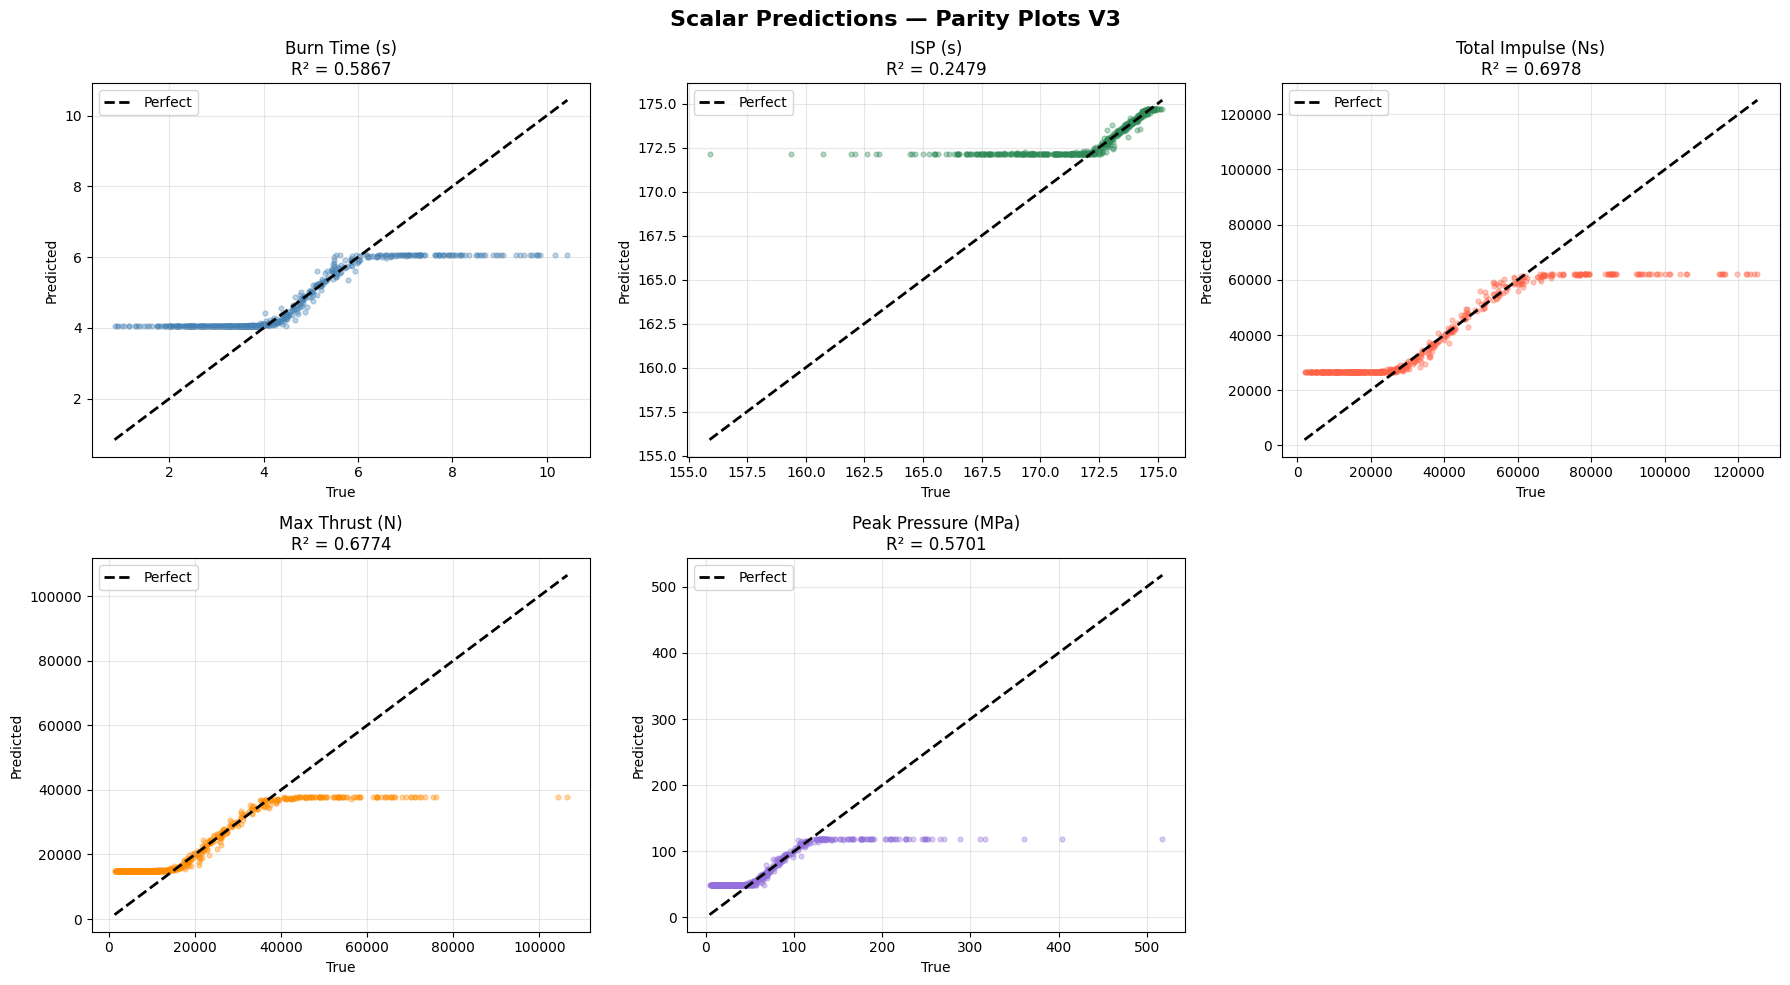

✅ Parity plots saved


In [36]:
# ===================================================================
# CELL 13: Scalar Parity Plots
# ===================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scalar Predictions — Parity Plots V3', fontsize=16, fontweight='bold')

scalar_names_short = ['Burn Time (s)', 'ISP (s)', 'Total Impulse (Ns)',
                       'Max Thrust (N)', 'Peak Pressure (MPa)']
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange', 'mediumpurple']

for i in range(5):
    ax = axes[i // 3, i % 3]
    tv, pv = sc_true[:, i], sc_pred[:, i]
    ax.scatter(tv, pv, alpha=0.35, s=12, color=colors[i])
    lo, hi = min(tv.min(), pv.min()), max(tv.max(), pv.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=2, label='Perfect')
    r2 = r2_score(tv, pv)
    ax.set_title(f'{scalar_names_short[i]}\nR² = {r2:.4f}')
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.legend(); ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig('scalar_parity_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Parity plots saved')

In [37]:
# ===================================================================
# CELL 14: Save Model
# ===================================================================
model_v3.save('finocyl_forward_v3_final.keras')
print('✅ Model saved: finocyl_forward_v3_final.keras')

for f in ['finocyl_forward_v3_final.keras', 'fin_v3_best.keras',
          'fin_v3_scaler_X.pkl', 'fin_v3_scaler_ys.pkl', 'fin_v3_norm_params.pkl',
          'training_history_v3.png', 'predictions_vs_true_v3.png',
          'smoothness_comparison_v3.png', 'scalar_parity_v3.png',
          'smoothing_demo.png']:
    if os.path.exists(f):
        print(f'  ✅ {f:<48} ({os.path.getsize(f)/1024:.1f} KB)')
    else:
        print(f'  ❌ {f}')

✅ Model saved: finocyl_forward_v3_final.keras
  ✅ finocyl_forward_v3_final.keras                   (28598.9 KB)
  ✅ fin_v3_best.keras                                (28598.9 KB)
  ✅ fin_v3_scaler_X.pkl                              (0.6 KB)
  ✅ fin_v3_scaler_ys.pkl                             (0.7 KB)
  ✅ fin_v3_norm_params.pkl                           (0.1 KB)
  ✅ training_history_v3.png                          (241.2 KB)
  ✅ predictions_vs_true_v3.png                       (814.2 KB)
  ✅ smoothness_comparison_v3.png                     (66.5 KB)
  ✅ scalar_parity_v3.png                             (250.7 KB)
  ✅ smoothing_demo.png                               (62.7 KB)


In [38]:
# ===================================================================
# CELL 15: Prediction Function V3
# ===================================================================
def predict_finocyl_v3(
    diameter, length, core_diameter,
    num_fins, fin_length, fin_width,
    throat_diameter, exit_diameter,
    plot=True, smooth_output=True
):
    """
    التنبؤ بأداء محرك Finocyl — V3

    Parameters
    ----------
    diameter, length, core_diameter : أبعاد الجسم والقلب (cm)
    num_fins, fin_length, fin_width : عدد الزعانف وأبعادها
    throat_diameter, exit_diameter  : أبعاد الفوهة (cm)
    smooth_output : bool — تنعيم إضافي خفيف على الـ output
                   (للعرض فقط، لا يؤثر على الـ scalars)
    """
    norm_params = joblib.load('fin_v3_norm_params.pkl')
    T_MAX = norm_params['thrust_max']
    P_MAX = norm_params['pres_max']

    inp_arr    = np.array([[diameter, length, core_diameter, num_fins,
                             fin_length, fin_width, throat_diameter, exit_diameter]],
                           dtype=np.float32)
    inp_scaled = s_X.transform(inp_arr)

    preds = model_v3.predict(inp_scaled, verbose=0)

    thrust_curve   = np.clip(preds[0][0] * T_MAX, 0, None)
    pressure_curve = np.clip(preds[1][0] * P_MAX, 0, None)

    # Optional light post-smoothing للعرض (لا يغير القيم المتوقعة)
    if smooth_output:
        thrust_curve   = np.clip(savgol_filter(thrust_curve,   window_length=11, polyorder=3), 0, None)
        pressure_curve = np.clip(savgol_filter(pressure_curve, window_length=11, polyorder=3), 0, None)

    sc_log    = s_ys.inverse_transform(preds[2])
    sc_vals   = np.expm1(sc_log)[0]

    burn_time     = max(float(sc_vals[0]), 0.1)
    isp           = max(float(sc_vals[1]), 1.0)
    total_impulse = max(float(sc_vals[2]), 1.0)
    max_thrust_sc = max(float(sc_vals[3]), 1.0)
    peak_pres     = max(float(sc_vals[4]), 0.01)

    time_steps    = np.linspace(0, burn_time, N_POINTS)
    calc_impulse  = float(np.trapz(thrust_curve, time_steps))

    print('\n' + '=' * 58)
    print('   Finocyl Forward V3 — Prediction Results')
    print('=' * 58)
    print(f'  Burn Time          : {burn_time:.3f} s')
    print(f'  ISP                : {isp:.2f} s')
    print(f'  Total Impulse      : {total_impulse:.2f} N·s')
    print(f'  Impulse (from ∫F dt): {calc_impulse:.2f} N·s')
    print(f'  Max Thrust (scalar): {max_thrust_sc:.2f} N')
    print(f'  Max Thrust (curve) : {float(thrust_curve.max()):.2f} N')
    print(f'  Peak Pressure      : {peak_pres:.3f} MPa')
    print(f'  Curve TV (thrust)  : {float(np.mean(np.abs(np.diff(thrust_curve)))):.2f} ↓smoother<100')
    print('=' * 58)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Finocyl V3 — Predicted Performance', fontsize=13, fontweight='bold')

        axes[0].fill_between(time_steps, thrust_curve, alpha=0.2, color='red')
        axes[0].plot(time_steps, thrust_curve, 'r-', lw=2.5)
        axes[0].set_title(f'Thrust Curve  Max={thrust_curve.max():.0f} N')
        axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
        axes[0].set_ylim(bottom=0); axes[0].grid(True, alpha=0.3)

        axes[1].fill_between(time_steps, pressure_curve, alpha=0.2, color='blue')
        axes[1].plot(time_steps, pressure_curve, 'b-', lw=2.5)
        axes[1].set_title(f'Pressure Curve  Max={pressure_curve.max():.2f} MPa')
        axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
        axes[1].set_ylim(bottom=0); axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        'thrust_curve'   : thrust_curve,
        'pressure_curve' : pressure_curve,
        'time_steps'     : time_steps,
        'burn_time'      : burn_time,
        'isp'            : isp,
        'total_impulse'  : total_impulse,
        'max_thrust'     : float(thrust_curve.max()),
        'peak_pressure'  : float(pressure_curve.max()),
    }

print('✅ predict_finocyl_v3() defined')
print('\nExample:')
print('  result = predict_finocyl_v3(')
print('      diameter=16, length=50, core_diameter=3,')
print('      num_fins=6, fin_length=1, fin_width=0.6,')
print('      throat_diameter=1.8, exit_diameter=2.7')
print('  )')

✅ predict_finocyl_v3() defined

Example:
  result = predict_finocyl_v3(
      diameter=16, length=50, core_diameter=3,
      num_fins=6, fin_length=1, fin_width=0.6,
      throat_diameter=1.8, exit_diameter=2.7
  )



   Finocyl Forward V3 — Prediction Results
  Burn Time          : 4.050 s
  ISP                : 172.35 s
  Total Impulse      : 26491.07 N·s
  Impulse (from ∫F dt): 30077.01 N·s
  Max Thrust (scalar): 15015.48 N
  Max Thrust (curve) : 12482.38 N
  Peak Pressure      : 48.492 MPa
  Curve TV (thrust)  : 151.58 ↓smoother<100


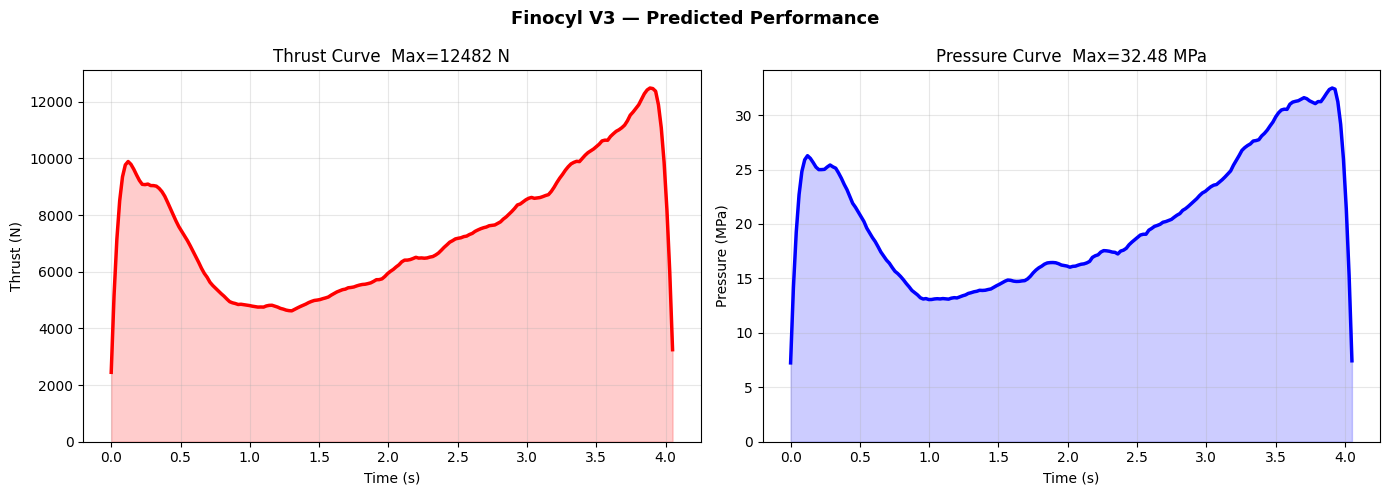

In [39]:
result = predict_finocyl_v3(
      diameter=10, length=90, core_diameter=2,
      num_fins=10, fin_length=1, fin_width=0.2,
      throat_diameter=1.9, exit_diameter=2.85
  )

Testing with a real design from the dataset...
{'Diameter': np.float32(14.0), 'Length': np.float32(20.0), 'Core_Diameter': np.float32(3.0), 'Number_Of_Fins': np.float32(4.0), 'Fin_Length': np.float32(1.0), 'Fin_Width': np.float32(0.6), 'Throat_Diameter': np.float32(1.1), 'Exit_Diameter': np.float32(1.65)}

   Finocyl Forward V3 — Prediction Results
  Burn Time          : 6.028 s
  ISP                : 172.12 s
  Total Impulse      : 26485.44 N·s
  Impulse (from ∫F dt): 8074.10 N·s
  Max Thrust (scalar): 14992.31 N
  Max Thrust (curve) : 2744.06 N
  Peak Pressure      : 48.488 MPa
  Curve TV (thrust)  : 36.52 ↓smoother<100


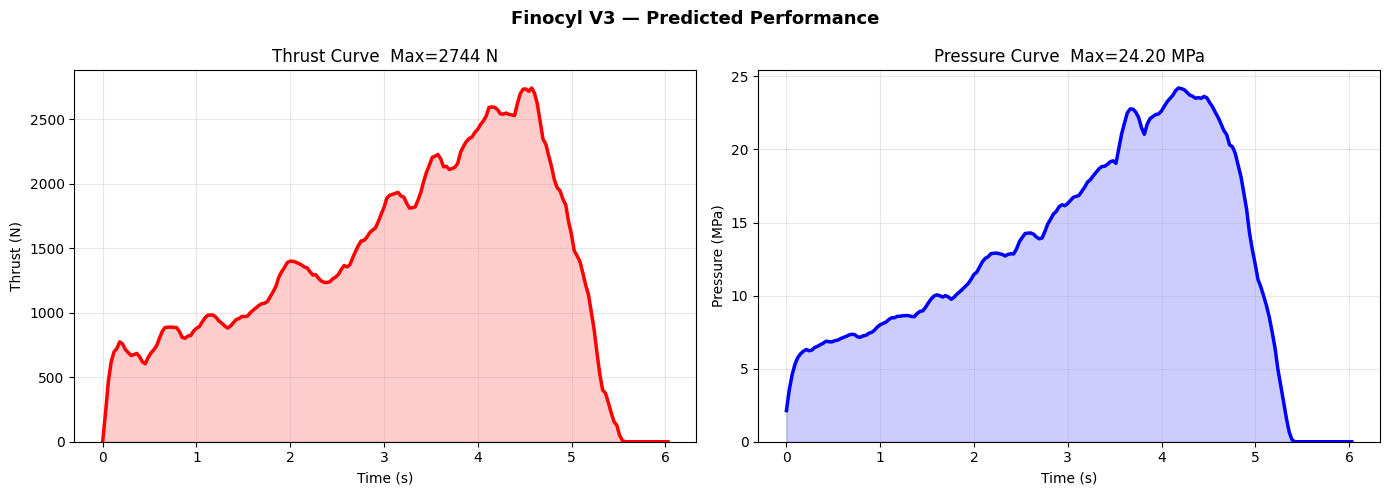


Single-design verification:
  Thrust   R²   : 0.9191
  Pressure R²   : 0.9232
  True  max F   : 3312.69 N
  Pred  max F   : 2744.06 N
  Error %       : 17.17%


In [40]:
# ===================================================================
# CELL 16: Test with a Real Design
# ===================================================================
test_sample_idx = 0
true_feats = X_feats[test_idx[test_sample_idx]]

print('Testing with a real design from the dataset...')
print(dict(zip(FEATURE_COLS, true_feats)))

result = predict_finocyl_v3(
    diameter       = true_feats[0],
    length         = true_feats[1],
    core_diameter  = true_feats[2],
    num_fins       = true_feats[3],
    fin_length     = true_feats[4],
    fin_width      = true_feats[5],
    throat_diameter= true_feats[6],
    exit_diameter  = true_feats[7],
    smooth_output  = True
)

true_thrust_s = Yt_test[test_sample_idx] * T_MAX
true_pres_s   = Yp_test[test_sample_idx] * P_MAX

t_r2 = r2_score(true_thrust_s, result['thrust_curve'])
p_r2 = r2_score(true_pres_s,   result['pressure_curve'])

print(f'\nSingle-design verification:')
print(f'  Thrust   R²   : {t_r2:.4f}')
print(f'  Pressure R²   : {p_r2:.4f}')
print(f'  True  max F   : {true_thrust_s.max():.2f} N')
print(f'  Pred  max F   : {result["max_thrust"]:.2f} N')
print(f'  Error %       : {abs(true_thrust_s.max() - result["max_thrust"]) / true_thrust_s.max() * 100:.2f}%')

## 📋 ملخص V3 — Anti-Vibration Edition

### سبب الـ Vibration في V2 (3 مستويات)

**المستوى 1 — البيانات:**
- `interp1d(kind='linear')` يحتفظ بكل spike في البيانات الخام
- الموديل يتعلم يُقلّد هذا الـ noise لأنه جزء من الـ target
- **الحل:** Savitzky-Golay smoothing على الـ targets قبل التدريب

**المستوى 2 — Loss Function:**
- `shape_mae_loss` في V2 تعاقب فقط على الفرق في القيمة الإجمالية
- لا تعاقب على التغيير المفاجئ بين نقطتين متجاورتين
- **الحل:** Total Variation (TV) Loss = `Σ|y[i+1] - y[i]|²`

**المستوى 3 — Architecture:**
- `Conv1DTranspose` يُدخل zeros بين النقاط أثناء الـ upsampling
- هذه الـ zeros تُسبب "checkerboard artifacts" (ظاهرة معروفة)
- **الحل:** `UpSampling1D` (يكرر القيمة) + `Conv1D` (يُنعّم) بدل ConvTranspose

### النتيجة المتوقعة
- منحنيات Pred أكثر نعومة بشكل واضح
- R² يبقى على نفس المستوى أو يتحسن
- TV score للـ Pred يقترب من TV score للـ True